# Week 3 — Wednesday: Hough Transforms

## Learning Objectives
- Understand the Hough line transform (ρ, θ parameterization)
- Learn the Hough circle transform
- Apply line and circle detection to real images
- Build lane line and coin detectors

## Key Concepts
1. **Hough Line Transform**: (ρ, θ) parameter space
2. **Hough Circle Transform**: Circle parameter space
3. **Accumulator Array**: Voting mechanism
4. **Line Detection Pipeline**: Edge → Hough → Line extraction
5. **Circle Detection Pipeline**: Blur → Edge → Hough circle

## Section 1: Hough Line Transform Theory

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)

### 1.1 Understanding Hough Space

**Cartesian space (x, y)**: Line = y = mx + c (not suitable for vertical lines)

**Hough space (ρ, θ)**:
- Each line in Cartesian space is represented as a point in Hough space
- Each point in Cartesian space traces a sinusoidal curve in Hough space
- Where curves intersect → line found

**Parameterization**: ρ = x·cos(θ) + y·sin(θ)
- ρ: perpendicular distance from origin to line
- θ: angle of perpendicular (0° to 180°)

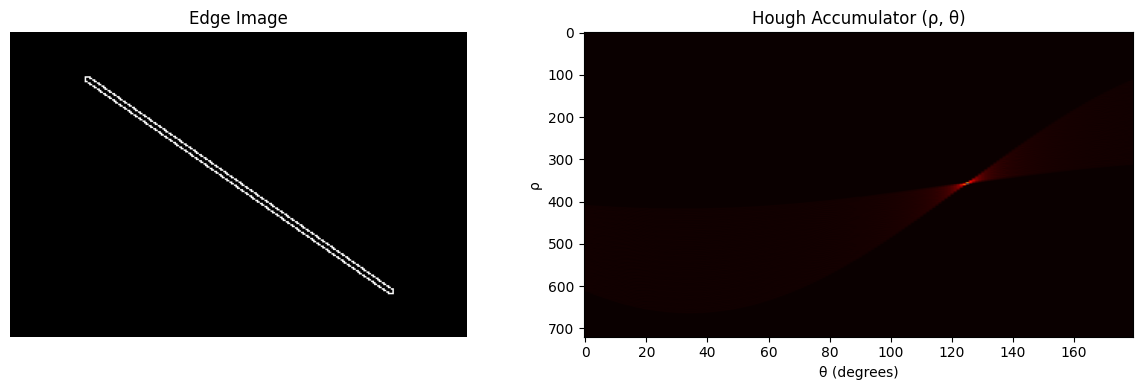

Accumulator shape: (720, 180)
Peak value: 246.0


In [2]:
# Visualize Hough space transformation
# Create a simple image with a line
img = np.zeros((200, 300, 3), dtype=np.uint8)
cv2.line(img, (50, 30), (250, 170), (255, 255, 255), 2)

# Convert to grayscale and apply Canny
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(edges, cmap='gray')
axes[0].set_title('Edge Image')
axes[0].axis('off')

# Demonstrate manual Hough transform visualization
# Find points on edge
points = np.where(edges > 0)
y_points, x_points = points[0], points[1]

# Create Hough accumulator
theta_range = np.arange(0, 180, 1) * np.pi / 180
rho_max = int(np.sqrt(img.shape[0]**2 + img.shape[1]**2))
accumulator = np.zeros((2*rho_max, 180))

# Voting: each point votes for all possible lines
for x, y in zip(x_points, y_points):
    for theta_idx, theta in enumerate(theta_range):
        rho = int(x * np.cos(theta) + y * np.sin(theta))
        rho_idx = rho + rho_max
        if 0 <= rho_idx < 2*rho_max:
            accumulator[rho_idx, theta_idx] += 1

axes[1].imshow(accumulator, cmap='hot', aspect='auto')
axes[1].set_title('Hough Accumulator (ρ, θ)')
axes[1].set_xlabel('θ (degrees)')
axes[1].set_ylabel('ρ')
plt.tight_layout()
plt.show()

print(f"Accumulator shape: {accumulator.shape}")
print(f"Peak value: {accumulator.max()}")

## Section 2: OpenCV Hough Line Transform

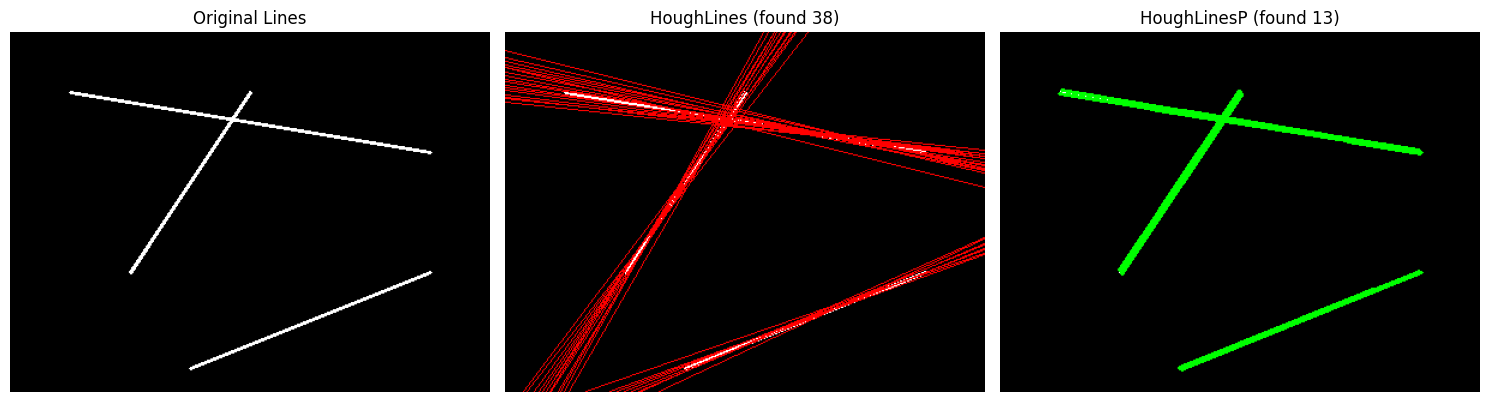

In [3]:
# HoughLines: Standard Hough transform
# HoughLinesP: Probabilistic Hough transform (returns line segments)

# Create test image with multiple lines
line_img = np.zeros((300, 400, 3), dtype=np.uint8)
cv2.line(line_img, (50, 50), (350, 100), (255, 255, 255), 2)
cv2.line(line_img, (100, 200), (200, 50), (255, 255, 255), 2)
cv2.line(line_img, (150, 280), (350, 200), (255, 255, 255), 2)

gray = cv2.cvtColor(line_img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

# Hough Line Transform (returns ρ, θ pairs)
lines = cv2.HoughLines(edges, rho=1, theta=np.pi/180, threshold=30)

# Probabilistic Hough Line Transform (returns endpoints)
linesP = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=30,
                          minLineLength=50, maxLineGap=10)

# Draw detected lines
hough_img = line_img.copy()

if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 500 * (-b))
        y1 = int(y0 + 500 * a)
        x2 = int(x0 - 500 * (-b))
        y2 = int(y0 - 500 * a)
        cv2.line(hough_img, (x1, y1), (x2, y2), (0, 0, 255), 1)

# Draw probabilistic lines
houghP_img = line_img.copy()
if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        cv2.line(houghP_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Lines')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(hough_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'HoughLines (found {len(lines) if lines is not None else 0})')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(houghP_img, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'HoughLinesP (found {len(linesP) if linesP is not None else 0})')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## Section 3: Lane Detection Demo

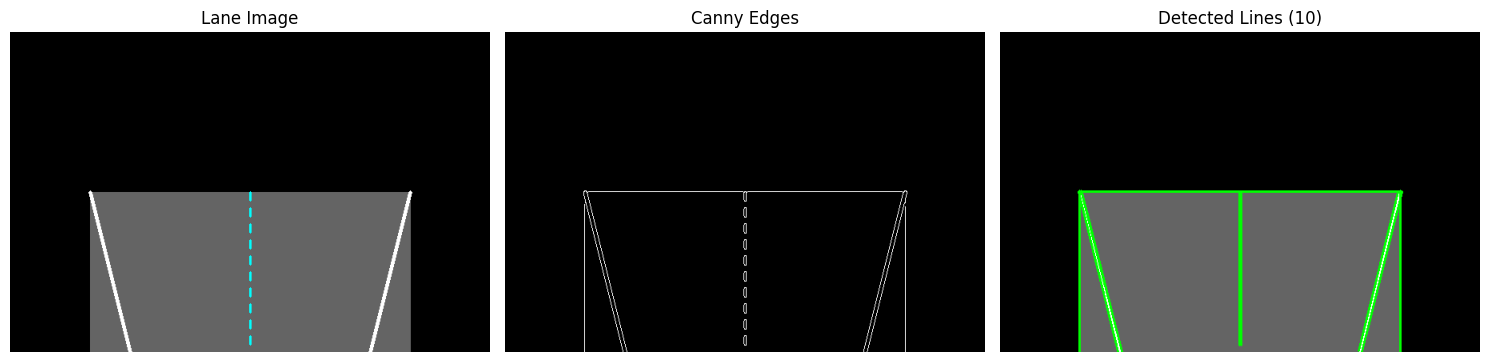

In [4]:
# Simulate a lane detection scenario
lane_img = np.zeros((400, 600, 3), dtype=np.uint8)
# Road area (gray)
cv2.rectangle(lane_img, (100, 200), (500, 400), (100, 100, 100), -1)
# Left lane
cv2.line(lane_img, (100, 200), (150, 400), (255, 255, 255), 3)
# Right lane
cv2.line(lane_img, (500, 200), (450, 400), (255, 255, 255), 3)
# Center divider
for i in range(200, 400, 20):
    cv2.line(lane_img, (300, i), (300, i+10), (255, 255, 0), 2)

gray = cv2.cvtColor(lane_img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

# Detect lines
linesP = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=20,
                          minLineLength=30, maxLineGap=10)

detected_img = lane_img.copy()
if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        cv2.line(detected_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cv2.cvtColor(lane_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Lane Image')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edges')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(detected_img, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Detected Lines ({len(linesP) if linesP is not None else 0})')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## Section 4: Hough Circle Transform

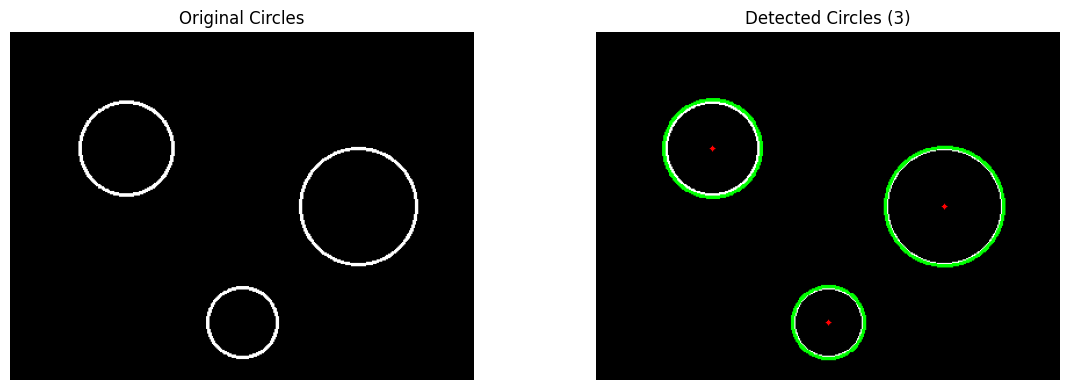


Detected 3 circles:
  Circle 0: center=(300, 150), radius=51
  Circle 1: center=(100, 100), radius=42
  Circle 2: center=(200, 250), radius=31


In [5]:
# Create image with circles
circle_img = np.zeros((300, 400, 3), dtype=np.uint8)
cv2.circle(circle_img, (100, 100), 40, (255, 255, 255), 2)
cv2.circle(circle_img, (300, 150), 50, (255, 255, 255), 2)
cv2.circle(circle_img, (200, 250), 30, (255, 255, 255), 2)

gray = cv2.cvtColor(circle_img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Hough Circle Transform
circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1, minDist=50,
                            param1=50, param2=30, minRadius=10, maxRadius=100)

detected_circles_img = circle_img.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    for circle in circles[0, :]:
        x, y, r = circle
        # Draw circle outline
        cv2.circle(detected_circles_img, (x, y), r, (0, 255, 0), 2)
        # Draw center
        cv2.circle(detected_circles_img, (x, y), 2, (0, 0, 255), -1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(circle_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Circles')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(detected_circles_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detected Circles ({len(circles[0]) if circles is not None else 0})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

if circles is not None:
    print(f"\nDetected {len(circles[0])} circles:")
    for i, circle in enumerate(circles[0, :]):
        x, y, r = circle
        print(f"  Circle {i}: center=({x}, {y}), radius={r}")

## Section 5: Coin Detector

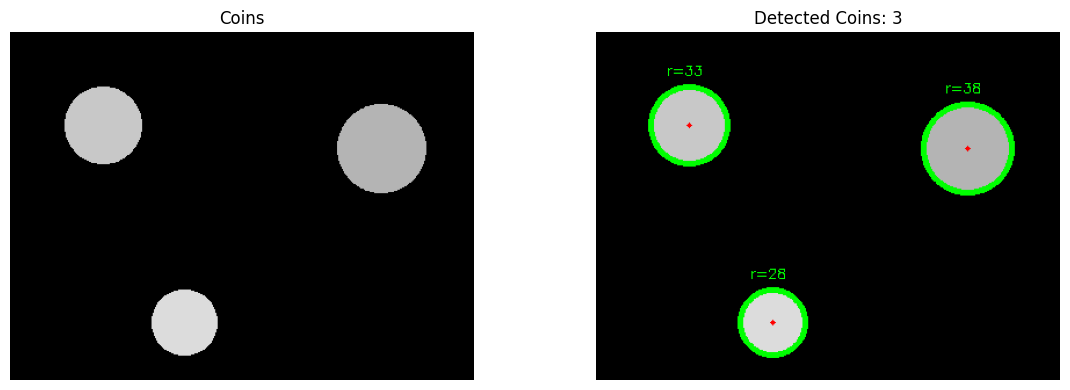


Coin Detection Results:
Total coins detected: 3
Total coin area: 10420.66 pixels²


In [6]:
# Create image simulating coins
coin_img = np.zeros((300, 400, 3), dtype=np.uint8)
# Filled circles to simulate coins
cv2.circle(coin_img, (80, 80), 35, (200, 200, 200), -1)
cv2.circle(coin_img, (80, 80), 35, (0, 0, 0), 2)
cv2.circle(coin_img, (320, 100), 40, (180, 180, 180), -1)
cv2.circle(coin_img, (320, 100), 40, (0, 0, 0), 2)
cv2.circle(coin_img, (150, 250), 30, (220, 220, 220), -1)
cv2.circle(coin_img, (150, 250), 30, (0, 0, 0), 2)

gray = cv2.cvtColor(coin_img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (7, 7), 0)

# Detect coins
circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1, minDist=60,
                            param1=50, param2=20, minRadius=20, maxRadius=50)

detected_coin_img = coin_img.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    for circle in circles[0, :]:
        x, y, r = circle
        cv2.circle(detected_coin_img, (x, y), r, (0, 255, 0), 3)
        cv2.circle(detected_coin_img, (x, y), 2, (0, 0, 255), -1)
        # Add text
        cv2.putText(detected_coin_img, f"r={r}", (x-20, y-r-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(coin_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Coins')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(detected_coin_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detected Coins: {len(circles[0]) if circles is not None else 0}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

if circles is not None:
    print(f"\nCoin Detection Results:")
    print(f"Total coins detected: {len(circles[0])}")
    total_area = sum([np.pi * (c[2]**2) for c in circles[0, :]])
    print(f"Total coin area: {total_area:.2f} pixels²")

## Section 6: Key Takeaways

1. **Hough Transform** converts global features to local features in parameter space
2. **Line detection**: (ρ, θ) parameterization handles vertical lines elegantly
3. **HoughLinesP** faster, returns segments (better for line extraction)
4. **Circle detection**: Extends to 3D parameter space (x, y, r)
5. **Pipeline**: Blur → Edge detection → Hough → Validation
6. **Applications**: Lane detection, coin counting, industrial inspection

## Exercises

1. Implement a filter to detect only horizontal or vertical lines.
2. Create a road/lane analyzer that segments lanes and counts them.
3. Implement multi-scale circle detection (coins of different sizes).
4. Build a Hough-based circle vs non-circle classifier.